# 1️. Environment Setup

### Terrain definitions

In [1]:
# --- Cell 1: Define Terrain Types and Costs ---

# Terrain type constants
FLAT = "flat"
SANDY = "sandy"
SAND_TRAP = "sand_trap"          # hazardous
ROCKY = "rocky"                  # impassable obstacle
CLIFF = "cliff"                  # impassable obstacle
RADIATION_SPOT = "radiation_spot"  # hazardous
RECHARGE = "recharge_station"
LANDMARK = "landmark"

# Terrain movement cost (battery usage per step)
TERRAIN_COST = {
    FLAT: 5,
    SANDY: 10,
    SAND_TRAP: 15,
    RADIATION_SPOT: 15,
    ROCKY: 1000,      # impassable
    CLIFF: 1000,      # impassable
    RECHARGE: 0,
    LANDMARK: 5       # same as flat by default
}

### Grid Matrix

In [2]:
matrix = [
    [
        ROCKY, ROCKY, ROCKY, ROCKY, CLIFF, SANDY, FLAT, CLIFF, ROCKY, FLAT, FLAT, CLIFF, CLIFF, SAND_TRAP, CLIFF, FLAT,
        ROCKY, CLIFF, CLIFF, RECHARGE, FLAT, RADIATION_SPOT, FLAT, FLAT, CLIFF, SANDY, ROCKY, FLAT, SANDY, CLIFF, ROCKY, FLAT
    ],
    [
        CLIFF, SANDY, SAND_TRAP, ROCKY, ROCKY, CLIFF, SAND_TRAP, SANDY, FLAT, ROCKY, CLIFF, ROCKY, CLIFF, FLAT, ROCKY, ROCKY,
        SAND_TRAP, SANDY, ROCKY, CLIFF, FLAT, SANDY, FLAT, CLIFF, ROCKY, FLAT, CLIFF, FLAT, ROCKY, FLAT, ROCKY, SANDY
    ],
    [
        FLAT, FLAT, FLAT, SANDY, FLAT, SANDY, FLAT , FLAT, SAND_TRAP, SANDY, SAND_TRAP, FLAT, ROCKY, CLIFF, ROCKY, CLIFF,
        FLAT, SAND_TRAP, FLAT, FLAT, CLIFF, CLIFF, FLAT, FLAT, CLIFF, CLIFF, ROCKY, CLIFF, FLAT, ROCKY, FLAT, ROCKY
    ],
    [
        ROCKY, SANDY, CLIFF, FLAT, FLAT, FLAT, FLAT, CLIFF, SANDY, FLAT, FLAT, FLAT, CLIFF, SAND_TRAP, RADIATION_SPOT, CLIFF, ROCKY, FLAT, CLIFF, FLAT, RADIATION_SPOT, FLAT, SANDY, SANDY, FLAT, CLIFF, ROCKY, SAND_TRAP, SAND_TRAP, FLAT, ROCKY, FLAT
    ],
    [
        ROCKY, SANDY, FLAT, ROCKY, CLIFF, CLIFF, CLIFF, SANDY, FLAT, SANDY, ROCKY, CLIFF, FLAT, FLAT, CLIFF, FLAT, CLIFF, FLAT, FLAT, SANDY, SAND_TRAP, FLAT, SAND_TRAP, ROCKY, CLIFF, CLIFF, FLAT, CLIFF, FLAT, FLAT, FLAT, FLAT
    ],
    [
        FLAT, SANDY, FLAT, SANDY, SANDY, FLAT, CLIFF, ROCKY, CLIFF, FLAT, SANDY, SANDY, SAND_TRAP, CLIFF, SANDY, CLIFF, FLAT, SANDY, FLAT, SANDY, FLAT, FLAT, FLAT, ROCKY, CLIFF, ROCKY, CLIFF, ROCKY, FLAT, FLAT, FLAT, FLAT
    ],
    [
        FLAT, FLAT, FLAT, FLAT, FLAT,  FLAT, CLIFF, FLAT, SANDY, ROCKY, FLAT, SAND_TRAP, ROCKY, ROCKY, CLIFF, FLAT, FLAT, SANDY, SAND_TRAP, CLIFF, ROCKY, ROCKY, FLAT, FLAT, CLIFF, ROCKY, CLIFF, CLIFF, FLAT, FLAT, FLAT, ROCKY 
    ],
    [
        FLAT, CLIFF, FLAT, FLAT, FLAT, FLAT, SAND_TRAP, ROCKY, ROCKY, CLIFF, ROCKY, FLAT, FLAT, SANDY, FLAT, CLIFF, ROCKY, SANDY, ROCKY, SAND_TRAP, CLIFF, ROCKY, FLAT, RADIATION_SPOT, FLAT, FLAT, ROCKY, CLIFF, ROCKY, ROCKY, ROCKY, CLIFF
    ],
    [
        FLAT, SANDY, FLAT, FLAT, ROCKY, FLAT, SANDY, SANDY, CLIFF, FLAT, CLIFF, FLAT, CLIFF, ROCKY, FLAT, SAND_TRAP, FLAT, FLAT, FLAT, ROCKY, ROCKY, ROCKY, ROCKY, FLAT, FLAT, FLAT, FLAT, FLAT, CLIFF, CLIFF, CLIFF, ROCKY
    ],
    [
        SANDY, FLAT, FLAT, CLIFF, CLIFF, CLIFF, CLIFF, FLAT, CLIFF, FLAT, CLIFF, CLIFF, SANDY, CLIFF, ROCKY, FLAT, CLIFF, CLIFF, SANDY, CLIFF, CLIFF, CLIFF, ROCKY, ROCKY, FLAT, CLIFF, FLAT, CLIFF, FLAT, FLAT, ROCKY, FLAT
    ],
    [
        CLIFF, CLIFF, FLAT, ROCKY, LANDMARK, RADIATION_SPOT, SANDY, CLIFF, ROCKY, CLIFF, ROCKY, ROCKY, FLAT, ROCKY, ROCKY, FLAT, ROCKY, ROCKY, FLAT, FLAT, ROCKY, FLAT, CLIFF, FLAT, FLAT, SANDY, CLIFF, CLIFF,CLIFF, FLAT, FLAT, FLAT
    ],
    [
        ROCKY, ROCKY, CLIFF, FLAT, CLIFF, ROCKY, CLIFF, ROCKY, FLAT, ROCKY, ROCKY, CLIFF, FLAT, CLIFF, FLAT, FLAT, CLIFF, CLIFF, SANDY, FLAT, RECHARGE, FLAT, FLAT, CLIFF, ROCKY, FLAT, ROCKY, CLIFF, FLAT, FLAT, CLIFF, FLAT
    ], 
    [
        FLAT, SANDY, FLAT, RADIATION_SPOT, FLAT, CLIFF, CLIFF, CLIFF, FLAT, CLIFF, ROCKY, CLIFF, CLIFF, FLAT, FLAT, FLAT, CLIFF, ROCKY, CLIFF, FLAT, FLAT, FLAT, FLAT, SANDY, CLIFF, SANDY, CLIFF, ROCKY, SANDY, CLIFF, FLAT, FLAT
    ],
    [
        FLAT, FLAT, FLAT, ROCKY, CLIFF, RADIATION_SPOT, CLIFF, FLAT, RADIATION_SPOT, ROCKY, ROCKY, CLIFF, ROCKY, FLAT, FLAT, RADIATION_SPOT, CLIFF, FLAT, FLAT, SANDY, FLAT, CLIFF, ROCKY, FLAT, FLAT, ROCKY, ROCKY, SANDY, FLAT, FLAT, SANDY, ROCKY
    ],
    [
        FLAT, FLAT, FLAT, SANDY, ROCKY, FLAT, ROCKY, CLIFF, FLAT, CLIFF, CLIFF, CLIFF, CLIFF, FLAT, CLIFF, FLAT, CLIFF, FLAT, FLAT, FLAT, CLIFF, ROCKY, CLIFF, FLAT, FLAT, ROCKY, CLIFF, FLAT, ROCKY, FLAT, RADIATION_SPOT, CLIFF
    ], 
    [
        FLAT, RECHARGE, SANDY, FLAT, SANDY, CLIFF, CLIFF, FLAT, ROCKY, ROCKY, ROCKY, ROCKY, ROCKY, SANDY, FLAT, SAND_TRAP, CLIFF, SANDY, ROCKY, CLIFF, CLIFF, SANDY, RADIATION_SPOT, CLIFF, FLAT, FLAT, FLAT, FLAT, FLAT, ROCKY, ROCKY, CLIFF
    ],
    [
        FLAT, CLIFF, FLAT, SAND_TRAP, FLAT, ROCKY, ROCKY, CLIFF, ROCKY, ROCKY, SANDY, CLIFF, SANDY, CLIFF, ROCKY, ROCKY, CLIFF, SANDY, FLAT, FLAT, CLIFF, ROCKY, FLAT, FLAT, LANDMARK, FLAT, FLAT, FLAT, CLIFF, CLIFF, ROCKY, CLIFF 
    ], 
    [
        ROCKY, ROCKY, FLAT, FLAT, SANDY, FLAT, SANDY, FLAT, FLAT, FLAT, FLAT, ROCKY, ROCKY, ROCKY, CLIFF, FLAT, FLAT, SANDY, FLAT, FLAT, FLAT, SANDY, FLAT, FLAT, CLIFF, FLAT, SANDY, FLAT, ROCKY, ROCKY, RECHARGE, CLIFF
    ],
    [
        FLAT, CLIFF, FLAT, FLAT, CLIFF, CLIFF, ROCKY, SANDY, FLAT, SANDY, FLAT, CLIFF, FLAT, ROCKY, ROCKY, FLAT, CLIFF, FLAT, SANDY, FLAT, SANDY, ROCKY, FLAT, ROCKY, ROCKY, FLAT, FLAT, ROCKY, CLIFF, ROCKY, ROCKY, ROCKY
    ],
    [
        RADIATION_SPOT, FLAT, FLAT, SANDY, FLAT, FLAT, SANDY, SANDY, FLAT, FLAT, CLIFF, ROCKY, CLIFF, FLAT, CLIFF, SANDY, FLAT, FLAT, FLAT, ROCKY, ROCKY, CLIFF, SANDY, FLAT, CLIFF, ROCKY, CLIFF, CLIFF, CLIFF, CLIFF, FLAT, FLAT
    ],
    [
        FLAT, CLIFF, CLIFF, ROCKY, CLIFF, FLAT, FLAT, FLAT, FLAT, FLAT, RADIATION_SPOT, FLAT, FLAT, CLIFF, CLIFF, FLAT, CLIFF, FLAT, SANDY, CLIFF, CLIFF, SANDY, FLAT, ROCKY, CLIFF, FLAT, ROCKY, CLIFF, ROCKY, CLIFF, ROCKY, FLAT
    ],
    [
        SANDY, FLAT, FLAT, CLIFF, ROCKY, CLIFF, SANDY, FLAT, CLIFF, FLAT, SANDY, FLAT, FLAT, CLIFF, ROCKY, ROCKY, ROCKY, FLAT, SAND_TRAP, CLIFF, ROCKY, FLAT, FLAT, FLAT, ROCKY, ROCKY, CLIFF, ROCKY, CLIFF, LANDMARK, FLAT, SANDY
    ],
    [
        CLIFF, FLAT, SANDY, ROCKY, CLIFF, FLAT, FLAT, CLIFF, ROCKY, FLAT, CLIFF, FLAT, FLAT, FLAT, CLIFF, CLIFF, FLAT, CLIFF, FLAT, CLIFF, FLAT, RADIATION_SPOT, FLAT, ROCKY, FLAT, FLAT, RADIATION_SPOT, SANDY, FLAT, FLAT, FLAT, FLAT 
    ],
    [
        FLAT, SAND_TRAP, SANDY, SANDY, ROCKY, SANDY, CLIFF, RECHARGE, FLAT, FLAT, ROCKY, FLAT, FLAT, SANDY, FLAT, ROCKY, FLAT, FLAT, CLIFF, ROCKY, FLAT, CLIFF, CLIFF, ROCKY, SANDY, FLAT, FLAT, FLAT, FLAT, CLIFF, CLIFF, ROCKY
    ],
    [
        SAND_TRAP, SANDY, FLAT, FLAT, CLIFF, FLAT, ROCKY, FLAT, ROCKY, CLIFF, CLIFF, FLAT, FLAT, CLIFF, SANDY, CLIFF, ROCKY, FLAT, FLAT, FLAT, SANDY, FLAT, ROCKY, SANDY, FLAT, FLAT, FLAT, SANDY, FLAT, SANDY, ROCKY, RADIATION_SPOT
    ],
    [
        FLAT, SANDY, FLAT, FLAT, FLAT, ROCKY, CLIFF, FLAT, FLAT, CLIFF, FLAT, ROCKY, CLIFF, FLAT, FLAT, SANDY, ROCKY, FLAT, SANDY, FLAT, FLAT, FLAT, CLIFF, FLAT, FLAT, CLIFF, ROCKY, FLAT, FLAT, FLAT, CLIFF, FLAT
    ],
    [
        FLAT, FLAT, ROCKY, CLIFF, FLAT, CLIFF, SANDY, ROCKY, CLIFF, FLAT, CLIFF, CLIFF, FLAT, FLAT, CLIFF, SANDY, CLIFF, FLAT, FLAT, CLIFF, CLIFF, ROCKY, CLIFF, ROCKY, CLIFF, ROCKY, FLAT, SANDY, CLIFF, CLIFF, ROCKY, ROCKY
    ],
    [
        FLAT, SAND_TRAP, FLAT, FLAT, SANDY, ROCKY, FLAT, FLAT, CLIFF, FLAT, ROCKY, CLIFF, ROCKY, FLAT, SANDY, CLIFF, ROCKY, CLIFF, CLIFF, FLAT, ROCKY, CLIFF, CLIFF, ROCKY, CLIFF, FLAT, FLAT, FLAT, FLAT, SANDY, FLAT, FLAT
    ],
    [
        FLAT, SANDY, ROCKY, FLAT, FLAT, CLIFF, FLAT, SANDY, ROCKY, FLAT, FLAT, FLAT, FLAT, CLIFF, FLAT, ROCKY, CLIFF, CLIFF, FLAT, FLAT, FLAT, ROCKY, SANDY, FLAT, FLAT, CLIFF, ROCKY, CLIFF, SANDY, SAND_TRAP, SANDY, SANDY
    ],
    [
        RECHARGE, RADIATION_SPOT, CLIFF, ROCKY, FLAT, ROCKY, FLAT, CLIFF, SANDY, ROCKY, CLIFF, ROCKY, CLIFF, ROCKY, ROCKY, CLIFF, FLAT, ROCKY, ROCKY, CLIFF, CLIFF, ROCKY, CLIFF, FLAT, ROCKY, ROCKY, CLIFF, FLAT, FLAT, CLIFF, CLIFF, ROCKY
    ],
    [
        CLIFF, ROCKY, RADIATION_SPOT, FLAT, CLIFF, FLAT, FLAT, ROCKY, ROCKY, CLIFF, SANDY, CLIFF, ROCKY, CLIFF, FLAT, FLAT, CLIFF, CLIFF, RADIATION_SPOT, CLIFF, CLIFF, ROCKY, ROCKY, LANDMARK, FLAT, CLIFF, CLIFF, FLAT, ROCKY, ROCKY, FLAT, SANDY
    ],
    [
        CLIFF, FLAT, FLAT, SANDY, FLAT, FLAT,FLAT, SANDY, SANDY, ROCKY, SANDY, CLIFF, SANDY, CLIFF, FLAT, RECHARGE, ROCKY, ROCKY, CLIFF, ROCKY, CLIFF, RADIATION_SPOT, FLAT, FLAT, FLAT, RECHARGE, FLAT, FLAT, SANDY, FLAT, CLIFF, CLIFF
    ]
]

### Environment classs

In [23]:
import math
class Environment:
    def __init__(self, matrix):
        self.grid = matrix
        self.rows = len(matrix)
        self.cols = len(matrix[0])

    def is_within_bounds(self, pos):
        x, y = pos
        return 0 <= x < self.rows and 0 <=y < self.cols

    def terrain_at(self, pos):
        x, y = pos
        return self.grid[x][y]

    def cost_at(self, pos):
        terrain = self.terrain_at(pos)
        return TERRAIN_COST.get(terrain, 5)

    def is_passable(self, pos):
        terrain = self.terrain_at(pos)
        return terrain not in (ROCKY, CLIFF)

    def find_all(self, terrain_type):
        print(terrain_type)
        locations = []
        for i in range(self.rows):
            for j in range(self.cols):
                if self.grid[i][j] == terrain_type:
                    locations.append((i, j))
        return locations

    def neighbors(self, pos):
        # it return the current cell all 4 direction neighbours.
        x, y = pos
        directions = [(0, 1), (1, 0), (0, -1), (-1, 0)]
        result = []
        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if self.is_within_bounds((nx, ny)) and self.is_passable((nx, ny)):
                result.append((nx, ny))
        return result

    def distance(self, a, b, mode="euclidean"):
        if mode == "euclidean":
            return math.sqrt((a[0]-b[0]) ** 2 + (a[1]-b[1])**2)
        else:
            return abs(a[0]-b[0]) + abs(a[1]-b[1])

### Visualization Function

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

def visualize_environment(env, rover_position=None, rover_image_path=None):
    """
    Visualize the 32x32 environment grid.
    Optionally overlay the rover image at the specified rover_position = (row, col).
    """
    color_map = {
        FLAT: "#99D38A",
        SANDY: "#eee78c",
        SAND_TRAP: "#FFD901",
        RADIATION_SPOT: "#2EFF00",
        ROCKY: "#927C86",
        CLIFF: "#6D4A2A",
        RECHARGE: "#0100FF",
        LANDMARK: "#ff4200",
    }
    # Create RGB image grid
    img = np.zeros((env.rows, env.cols, 3))
    for i in range(env.rows):
        for j in range(env.cols):
            rgb = mcolors.to_rgb(color_map[env.grid[i][j]])
            img[i, j, :] = rgb

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img, extent=[0, env.cols, env.rows, 0])

    # If a rover position + image are provided → overlay it
    if rover_position and rover_image_path:
        rover_img = mpimg.imread(rover_image_path)
        rover_size = 0.9  # slightly smaller than a grid cell
        x, y = rover_position[1], rover_position[0]
        ax.imshow(
            rover_img,
            extent=[x, x + rover_size, y + rover_size, y],
            zorder=5
        )
        plt.title(f"Rover Position at {rover_position}")
    else:
        plt.title("Planetary Exploration Rover Environment")

    # Optional grid lines for cell boundaries
    ax.set_xticks(np.arange(0, env.cols, 1))
    ax.set_yticks(np.arange(0, env.rows, 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(color='white', linewidth=0.5)
    plt.axis("off")

    # === Create legend patches ===
    legend_patches = [
        mpatches.Patch(color=color_map[FLAT], label="Flat"),
        mpatches.Patch(color=color_map[SANDY], label="Sandy"),
        mpatches.Patch(color=color_map[SAND_TRAP], label="Sand Trap (Hazard)"),
        mpatches.Patch(color=color_map[RADIATION_SPOT], label="Radiation Spot (Hazard)"),
        mpatches.Patch(color=color_map[ROCKY], label="Rocky (Impassable)"),
        mpatches.Patch(color=color_map[CLIFF], label="Cliff (Impassable)"),
        mpatches.Patch(color=color_map[RECHARGE], label="Recharge Station"),
        mpatches.Patch(color=color_map[LANDMARK], label="Landmark"),
    ]
    ax.legend(
        handles=legend_patches,
        loc="upper right",
        bbox_to_anchor=(1.45, 1.0),
        title="Terrain Legend",
        fontsize=9,
        title_fontsize=10
    )
    
    plt.show()

### Testing Function

Grid size: 32 x 32
Recharge stations found: [(0, 19), (11, 20), (15, 1), (17, 30), (23, 7), (29, 0), (31, 15), (31, 25)]
Landmarks found: [(10, 4), (16, 24), (21, 29), (30, 23)]


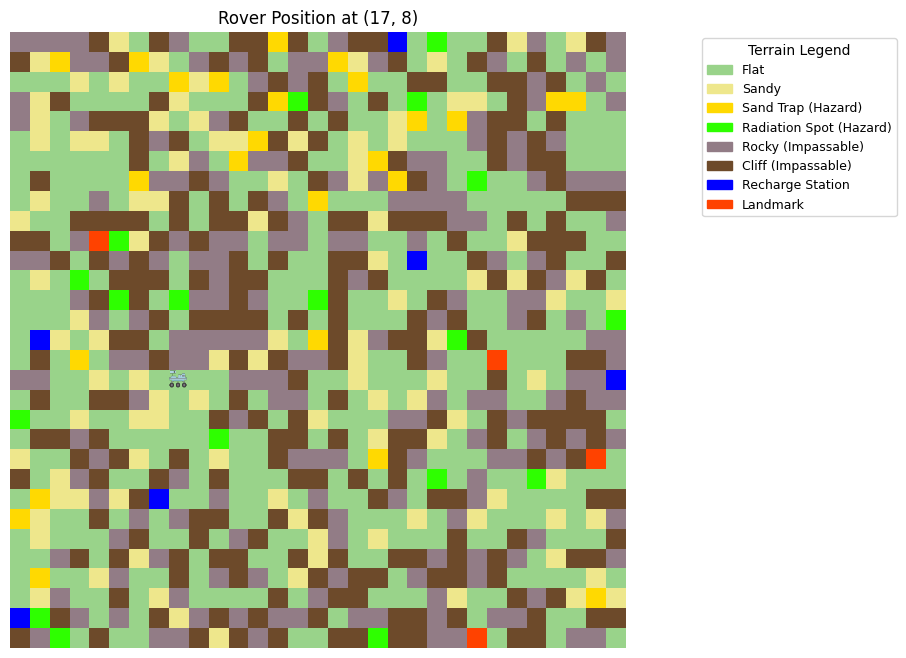

In [14]:
# Create the environment object
env = Environment(matrix)

# Example rover position (row, col)
rover_position = (17, 8)   # You can change this to move the rover
rover_image_path = "Assets/Rover.png"  # Adjust path if stored elsewhere

# Basic environment checks
print("Grid size:", env.rows, "x", env.cols)
print("Recharge stations found:", env.find_all(RECHARGE))
print("Landmarks found:", env.find_all(LANDMARK))

# Visualize grid + rover + legend
visualize_environment(env, rover_position, rover_image_path)


# 2️. Core Rover Logic

### Define Rover Class with Core Logic

In [ ]:

import random
class Rover:
    def __init__(self, env, start_pos=(0, 6), battery=100):
        if not env.is_passable(start_pos):
            raise ValueError(f"Invalid start position {start_pos}: not passable terrain ({env.terrain_at(start_pos)})")

        self.env = env
        self.position = start_pos
        self.battery = battery
        self.last_safe_cell = start_pos
        self.path_history = [start_pos]
        self.status = "exploring"
        self.hazard_detected = False

    def terrain_here(self):
        """Return terrain type at current rover position."""
        return self.env.terrain_at(self.position)

    def move_to(self, new_pos):
        """Move rover to a new position and update battery."""
        if not self.env.is_within_bounds(new_pos):
            print("Move blocked: out of bounds.")
            return False
        if not self.env.is_passable(new_pos):
            print("Move blocked: obstacle (rock/cliff).")
            return False

        terrain = self.env.terrain_at(new_pos)
        cost = TERRAIN_COST.get(terrain, 5)

        # Reduce battery
        self.battery -= cost * 0.01 * 100  # scale if needed (for simplicity, direct % here)
        if self.battery < 0:
            self.battery = 0

        self.position = new_pos
        self.path_history.append(new_pos)
        print(f"Moved to {new_pos} | Terrain: {terrain} | Battery: {self.battery:.1f}%")

        # Handle hazard or recharge
        self.reflex_check()
        return True

    # Reflex Behavior

    def reflex_check(self):
        terrain = self.env.terrain_at(self.position)
    
        # Store last safe cell
        if terrain not in [SAND_TRAP, RADIATION_SPOT]:
            self.last_safe_cell = self.position
    
        # Rule 1: If terrain is hazardous → stop and backtrack
        if terrain in [SAND_TRAP, RADIATION_SPOT]:
            print(f"⚠️ Hazard detected ({terrain})! Backtracking to last safe cell {self.last_safe_cell}")
            self.hazard_detected = True
            self.position = self.last_safe_cell
            self.path_history.append(self.last_safe_cell)
            return
    
        # Rule 2: Battery < 20% → go recharge
        if self.battery < 20 and self.status != "recharging":
            nearest_recharge = self.find_nearest(RECHARGE)
            if nearest_recharge:
                print(f"🔋 Battery low ({self.battery:.1f}%). Heading to recharge station {nearest_recharge}.")
                self.status = "recharging"
                self.path_history.append(nearest_recharge)
                self.recharge()
            return
    
        # Rule 3: Battery 20–25% and recharge nearby
        if 20 <= self.battery <= 25 and self.status != "recharging":
            nearest_recharge = self.find_nearest(RECHARGE)
            if nearest_recharge and self.env.distance(self.position, nearest_recharge) <= 2:
                print(f"⚡ Battery {self.battery:.1f}% and recharge nearby. Recharging now.")
                self.status = "recharging"
                self.path_history.append(nearest_recharge)
                self.recharge()
            return
    
        self.status = "exploring"

    # RECHARGE LOGIC
    
    def recharge(self):
        """Recharge instantly to 100%."""
        print("🔌 Recharging...")
        self.battery = 100
        self.status = "exploring"
        print("Fully recharged (100%). Resuming exploration.")

    # UTILITIES

    def find_nearest(self, terrain_type):
        """Return the nearest cell of a given type using Euclidean distance."""
        locations = self.env.find_all(terrain_type)
        if not locations:
            return None
        return min(locations, key=lambda loc: self.env.distance(self.position, loc))

    def random_move(self):
        """Move randomly to any neighboring cell (for testing reflex logic)."""
        neighbors = self.env.neighbors(self.position)
        if not neighbors:
            print("No available moves.")
            return False
        next_pos = random.choice(neighbors)
        return self.move_to(next_pos)
